In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive, runtime

drive.mount('/content/drive')

RUN_DIR = Path("/content/drive/MyDrive/CMPE401/YOLO/runs/visdrone_yolo11s_baseline7")

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Validation and Statistics

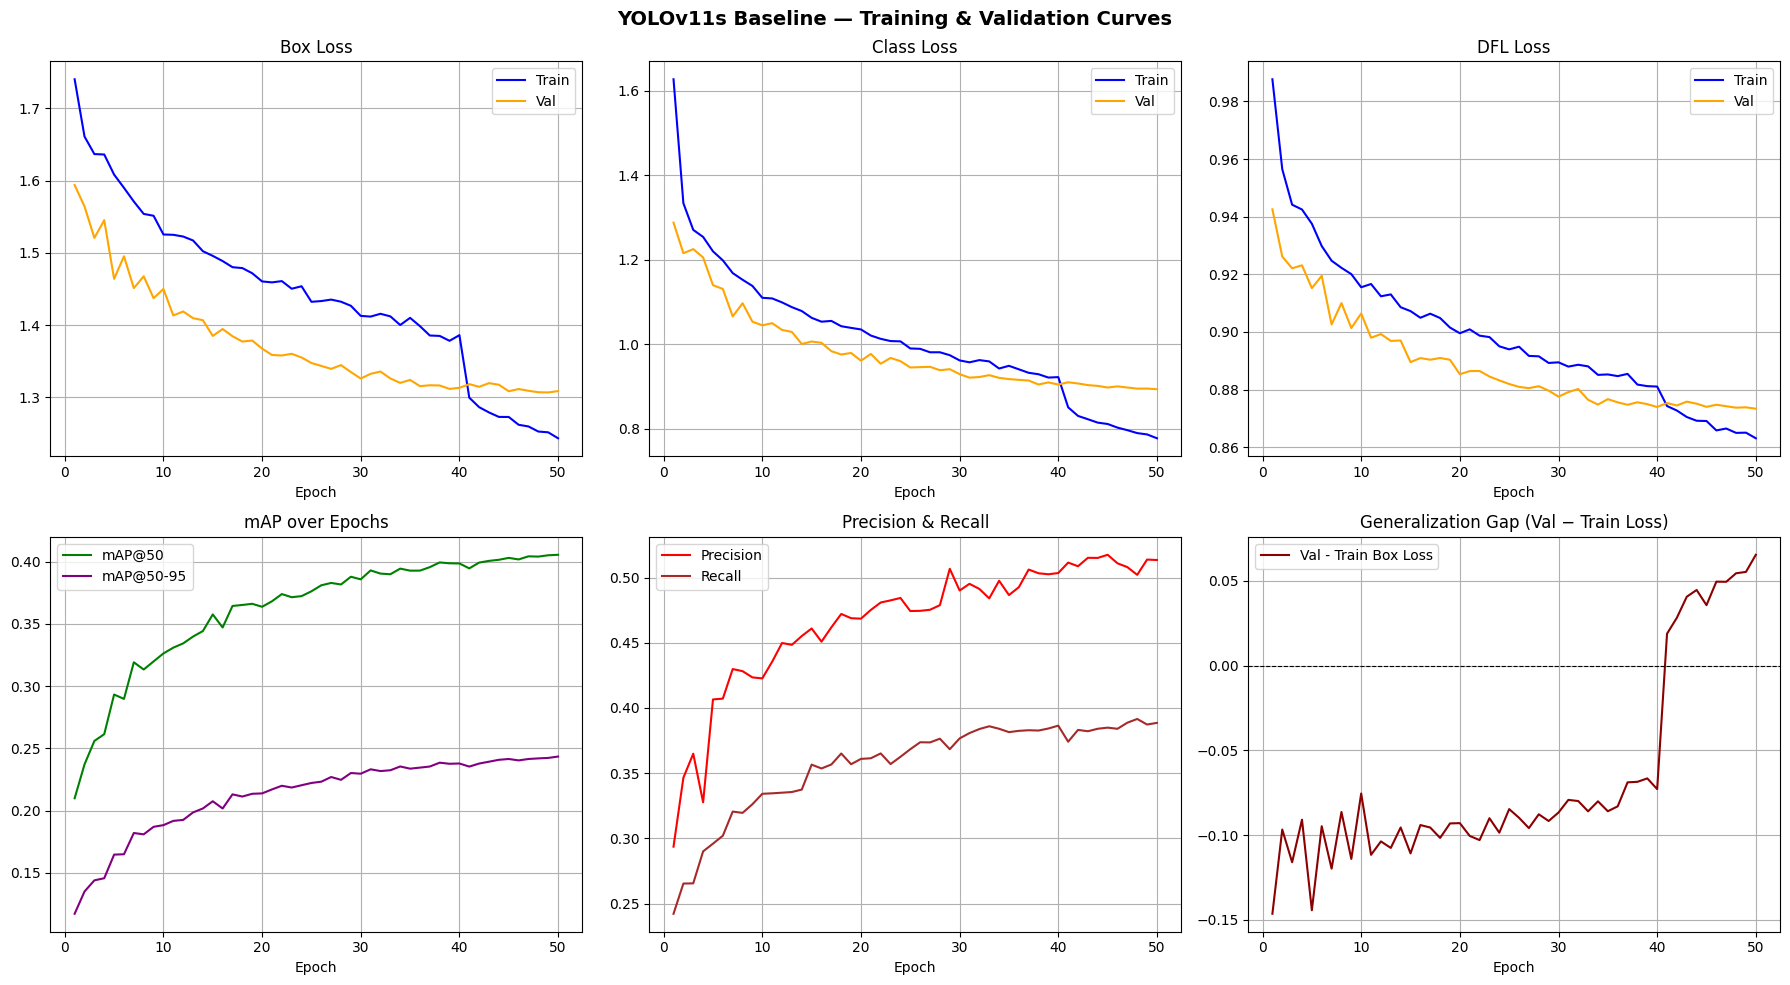

Saved → /content/drive/MyDrive/CMPE401/YOLO/runs/visdrone_yolo11s_baseline7/loss_analysis.png


In [ ]:
df = pd.read_csv(RUN_DIR / "results.csv")
df.columns = df.columns.str.strip()

epochs = df["epoch"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("YOLOv11s Baseline — Training & Validation Curves", fontsize=14, fontweight="bold")

# ── Loss curves ────────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs, df["train/box_loss"], label="Train", color="blue")
axes[0, 0].plot(epochs, df["val/box_loss"],   label="Val",   color="orange")
axes[0, 0].set_title("Box Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs, df["train/cls_loss"], label="Train", color="blue")
axes[0, 1].plot(epochs, df["val/cls_loss"],   label="Val",   color="orange")
axes[0, 1].set_title("Class Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].plot(epochs, df["train/dfl_loss"], label="Train", color="blue")
axes[0, 2].plot(epochs, df["val/dfl_loss"],   label="Val",   color="orange")
axes[0, 2].set_title("DFL Loss")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].legend()
axes[0, 2].grid(True)

# ── Metric curves ──────────────────────────────────────────────────────────────
axes[1, 0].plot(epochs, df["metrics/mAP50(B)"],    label="mAP@50",    color="green")
axes[1, 0].plot(epochs, df["metrics/mAP50-95(B)"], label="mAP@50-95", color="purple")
axes[1, 0].set_title("mAP over Epochs")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(epochs, df["metrics/precision(B)"], label="Precision", color="red")
axes[1, 1].plot(epochs, df["metrics/recall(B)"],    label="Recall",    color="brown")
axes[1, 1].set_title("Precision & Recall")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True)

# ── Train vs Val box loss gap (overfitting indicator) ──────────────────────────
gap = df["val/box_loss"] - df["train/box_loss"]
axes[1, 2].plot(epochs, gap, label="Val - Train Box Loss", color="darkred")
axes[1, 2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1, 2].set_title("Generalization Gap (Val − Train Loss)")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plot_path = RUN_DIR / "loss_analysis.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot_path}")